In [21]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0,1]
    rotation_range=20,        # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,    # Randomly shift images horizontally
    height_shift_range=0.2,   # Randomly shift images vertically
    shear_range=0.2,          # Shear transformation
    zoom_range=0.2,           # Zoom in randomly
    horizontal_flip=True,     # Flip images horizontally
    fill_mode='nearest'       # Fill pixels after transformations
)

In [23]:
validation_datagen = ImageDataGenerator(rescale=1./255)

In [65]:
train_generator = train_datagen.flow_from_directory(
    path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse'  # Use sparse for simpler label format
)

validation_generator = validation_datagen.flow_from_directory(
    path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse'
)


Found 245 images belonging to 3 classes.
Found 245 images belonging to 3 classes.


In [54]:
path = r"C:\Users\gaura\Desktop\ml practical"


In [55]:
# Compile model with correct loss function
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ for integer labels
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)


C:\Users\gaura\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6787 - loss: 0.6619 - val_accuracy: 0.6429 - val_loss: 0.6072
Epoch 2/20
1/7 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6875 - loss: 0.5685

C:\Users\gaura\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 379ms/step - accuracy: 0.6875 - loss: 0.5685 - val_accuracy: 0.5759 - val_loss: 0.7163
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6265 - loss: 0.6554 - val_accuracy: 0.7634 - val_loss: 0.5431
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 422ms/step - accuracy: 0.6562 - loss: 0.5398 - val_accuracy: 0.7143 - val_loss: 0.5553
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6281 - loss: 0.6241 - val_accuracy: 0.7455 - val_loss: 0.5423
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 362ms/step - accuracy: 0.8125 - loss: 0.4671 - val_accuracy: 0.7277 - val_loss: 0.5513
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6815 - loss: 0.5896 - val_accuracy: 0.7277 - val_loss: 0.5101
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.6562 - loss: 0.5798 - val_accuracy: 0.6875 - val_loss: 0.5902
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6382 - loss: 0.6208 - val_accuracy: 0.7098 - val_loss: 0.5123
Epoch 10/20

In [56]:
model.save('animal_classifier_model.h5')

In [57]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_animal(img_path):
    # Load image with target size
    img = image.load_img(img_path, target_size=(150, 150))
    # Convert image to array
    img_array = image.img_to_array(img)
    # Scale pixel values to [0,1]
    img_array = img_array / 255.0
    # Expand dims to add batch size dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict class probabilities
    predictions = model.predict(img_array)
    # Get the index of the highest probability
    predicted_class_index = np.argmax(predictions)
    # Map class index to class label
    class_labels = list(train_generator.class_indices.keys())
    predicted_label = class_labels[predicted_class_index]

    return predicted_label

In [58]:
img_path = rimg_path = r"C:\Users\gaura\Desktop\ml practical\Cat\Cat_10.jpg"
print(f"Predicted animal: {predict_animal(img_path)}")
print(f"Predicted animal: {predict_animal(img_path)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step
Predicted animal: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted animal: Cat


In [59]:
img_path = r"C:\Users\gaura\Desktop\ml practical\Dog\Dog_1.jpeg"
print(f"Predicted animal: {predict_animal(img_path)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted animal: Dog


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


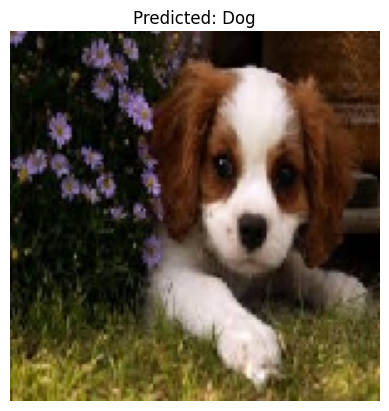

In [60]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_and_show(img_path):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions)
    class_labels = list(train_generator.class_indices.keys())
    predicted_label = class_labels[predicted_class_index]

    # Show image and prediction
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()

# Example usage
img_path = r"C:\Users\gaura\Desktop\ml practical\Dog\Dog_1.jpeg"
predict_and_show(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


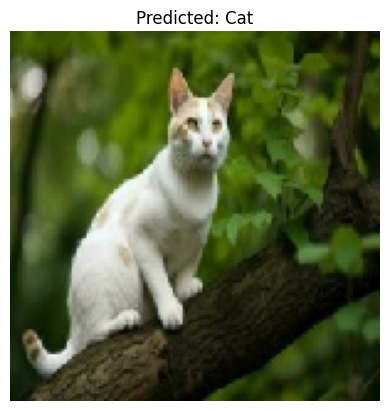

In [61]:
img_path = rimg_path = r"C:\Users\gaura\Desktop\ml practical\Cat\Cat_10.jpg"
predict_and_show(img_path)

In [62]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
print(accuracy_score)
print(confusion_matrix)
print(classification_report)

<function accuracy_score at 0x000002C092E930A0>
<function confusion_matrix at 0x000002C092E931C0>
<function classification_report at 0x000002C092EB0280>


In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# True and predicted labels
y_true = validation_generator.classes
y_pred_probs = model.predict(validation_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = y_pred[:len(y_true)]

# Accuracy and Confusion Matrix
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

# ✅ FIX: Only use target names for classes that appear in predictions
class_indices = validation_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
used_class_indices = sorted(np.unique(y_pred))
filtered_labels = [index_to_class[i] for i in used_class_indices]

# Classification report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=filtered_labels))


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step
Accuracy: 0.5265306122448979
Confusion Matrix:
 [[92 31]
 [85 37]]
Classification Report:
               precision    recall  f1-score   support

         Cat       0.52      0.75      0.61       123
         Dog       0.54      0.30      0.39       122

    accuracy                           0.53       245
   macro avg       0.53      0.53      0.50       245
weighted avg       0.53      0.53      0.50       245

